# BIRCH on Full Data
**BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies) by Group 3**

## Installing and Importing Required Libraries

Install matplotlib for visualization

In [1]:
!pip install matplotlib

Java is installed for PySpark

In [2]:
!sudo yum install -y java-11-amazon-corretto-headless

Last metadata expiration check: 0:10:33 ago on Sun Jul 26 12:41:21 2026.
Package java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn2023.x86_64 is already installed.
Dependencies resolved.
Nothing to do.
Complete!


In [3]:
import os
import glob

# Search for the installed Java directory
java_paths = glob.glob('/usr/lib/jvm/java-11*')

if java_paths:
    # Dynamically set the environment variable to the found path
    os.environ["JAVA_HOME"] = java_paths[0]
    print(f"JAVA_HOME successfully set to: {os.environ['JAVA_HOME']}")
else:
    print("Java not found. Did the yum install command work?")

JAVA_HOME successfully set to: /usr/lib/jvm/java-11-amazon-corretto.x86_64


Importing the necessary libraries for model training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import Birch
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

Setup a SparkSession

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark import StorageLevel
from pyspark.ml.functions import vector_to_array

spark = (
    SparkSession.builder
    .appName("BIRCH-Full-Data")
    .master("local[*]")
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "com.amazonaws.auth.InstanceProfileCredentialsProvider")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)

print("Spark ready:", spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/pytorch/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0270d02b-0bb0-44a0-822d-fe1f03340369;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 170ms :: artifacts dl 5ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|

26/07/26 12:51:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark ready: 3.3.0


Check if connection to s3 is stable

In [6]:
import boto3

s3 = boto3.client("s3")

try:
    print(s3.list_objects_v2(Bucket="dat204m-project-g3", MaxKeys=5))
except Exception as e:
    print(e)

{'ResponseMetadata': {'RequestId': 'A1ZTQE26JWCGGPN5', 'HostId': 'rrGG5cCLPnOHXXHxdCSMmOQKzd0/AtnQhlU1kf9xo/A/i0LxGCxs9YYfeXGt2G0QcocCBQDEeo0=', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amz-id-2': 'rrGG5cCLPnOHXXHxdCSMmOQKzd0/AtnQhlU1kf9xo/A/i0LxGCxs9YYfeXGt2G0QcocCBQDEeo0=', 'x-amz-request-id': 'A1ZTQE26JWCGGPN5', 'date': 'Sun, 26 Jul 2026 12:52:02 GMT', 'x-amz-bucket-region': 'us-east-1', 'content-type': 'application/xml', 'transfer-encoding': 'chunked', 'server': 'AmazonS3'}, 'RetryAttempts': 0}, 'IsTruncated': True, 'Contents': [{'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730-manifest.csv', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28, 45, tzinfo=tzlocal()), 'ETag': '"c90c48a2b97547599fca337a336b68a1"', 'ChecksumAlgorithm': ['SHA1'], 'ChecksumType': 'FULL_OBJECT', 'Size': 3240, 'StorageClass': 'STANDARD'}, {'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730.metadata', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28

## Reading and Stardardizing the Full Data

Read the Parquet file of the feature engineered full data

In [7]:
EDA_DATA_PATH = "s3a://dat204m-project-g3/feature_engineered_full/"
features_df = spark.read.parquet(EDA_DATA_PATH)

26/07/26 12:52:02 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Show the schema of the full data

In [8]:
features_df.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- views: long (nullable = true)
 |-- likes: long (nullable = true)
 |-- cart: long (nullable = true)
 |-- offers: long (nullable = true)
 |-- buy_start: long (nullable = true)
 |-- buy_comp: long (nullable = true)
 |-- unique_users: long (nullable = true)
 |-- unique_sessions: long (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- category_path: string (nullable = true)
 |-- cond_good: long (nullable = true)
 |-- cond_new: long (nullable = true)
 |-- cond_like_new: long (nullable = true)
 |-- cond_fair: long (nullable = true)
 |-- cond_poor: long (nullable = true)
 |-- cond_unknown: long (nullable = true)
 |-- log_views: double (nullable = true)
 |-- log_likes: double (nullable = true)
 |-- log_cart: double (nullable = true)
 |-- log_offers: double (nullable = true)
 |-- log_buy_start: double (nullable = true)
 |-- log_buy_comp: double (nullable = true)
 |-- log_users: double (null

Show the first five lines of the full data

In [9]:
features_df.show(5)

26/07/26 12:52:06 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Stage 2:============================================>              (3 + 1) / 4]

+----------+-----+-----+----+------+---------+--------+------------+---------------+------------------+--------------------+--------------------+---------+--------+-------------+---------+---------+------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+----------------+
|product_id|views|likes|cart|offers|buy_start|buy_comp|unique_users|unique_sessions|         avg_price|          brand_name|       category_path|cond_good|cond_new|cond_like_new|cond_fair|cond_poor|cond_unknown|         log_views|         log_likes|          log_cart|        log_offers|     log_buy_start|      log_buy_comp|         log_users|      log_sessions|         log_price|     log_cond_good|     log_cond_new|log_cond_like_new|    log_cond_fair|     log_cond_poor|log_cond_unknown|
+----------+----

To reduce recomputation and improve performance, DataFrame is cached in memory and spills excess data to disk when needed

In [10]:
features_df = features_df.persist(StorageLevel.MEMORY_AND_DISK)

In [11]:
# Materialize cache
features_df.count()

1383996

Frequency Encoding is applied for categorical columns 'brand_name' and 'category_path'

In [12]:
freq_cols = [
    "brand_name",
    "category_path"
]

features_encoded = features_df

for c in freq_cols:
    freq = (
        features_df.groupBy(c)
                   .count()
                   .withColumnRenamed("count", f"{c}_freq")
    )

    features_encoded = (
        features_encoded
        .join(freq, on=c, how="left")
    )

All numerical columns are combined into one single feature vector using VectorAssembler

In [13]:
numeric_features = [
    "log_views",
    "log_likes",
    "log_cart",
    "log_offers",
    "log_buy_comp",
    "log_buy_start",
    "log_users",
    "log_sessions",
    "log_price",
    "brand_name_freq",
    "category_path_freq",
    "log_cond_good",
    "log_cond_new",
    "log_cond_like_new",
    "log_cond_fair",
    "log_cond_poor",
    "log_cond_unknown"
]

assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="features_raw"
)

Standard scaling is applied to prevent features with larger numerical ranges from dominating the clustering process

In [14]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

Pipeline is run to apply the vectorizing and standard scaling to the full data

In [15]:
pipeline = Pipeline(stages=[
    assembler,
    scaler
])

In [16]:
pipeline_model = pipeline.fit(features_encoded)

In [17]:
birch_df = pipeline_model.transform(features_encoded)

## Initial Model Training

As we do not have any target data, we will be doing unsupervised modelling with BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

Convert Spark feature vectors to a NumPy array for scikit-learn Birch clustering

In [18]:
final_df = (birch_df.select("product_id", vector_to_array("features").alias("features")).toPandas())

X = np.vstack(final_df["features"]).astype(np.float32)

Initialize a Birch model

In [19]:
birch = Birch(
    n_clusters=10,
    threshold=2.0,
    branching_factor=100
)

Fit the model to the data and assign each a cluster

In [20]:
birch_clusters = birch.fit_predict(X)

Evaluation Metrics used for BIRCH are the following:

* Silhouette Score - Evaluates the similarity of an object to its own group relative to other groups, thereby reflecting the balance between cohesion and separation
* Davies-Bouldin Index - Quantifies group compactness and separation. A lower index signifies higher-quality clusters.
* Calinski–Harabasz Index - Used to compare different clustering results and help select the optimal number of clusters. A higher score indicates better-defined clusters with greater separation between clusters and higher compactness within clusters.

Based on Alshrouf, F., Masadeh, S., Al-Fraihat, D., & Al-Nsoor, R. (2025). Improving BIRCH hierarchical clustering algorithms for enhanced partitioning of medical data. Cluster Computing, 28(9), 600.

In [21]:
sil_score = silhouette_score(
    X,
    birch_clusters,
    sample_size=20000,
    random_state=42
)
dbi = davies_bouldin_score(X, birch_clusters)
chi = calinski_harabasz_score(X, birch_clusters)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {dbi:.4f}")
print(f"Calinski-Harabasz Index: {chi:.4f}")

Silhouette Score: 0.3843
Davies-Bouldin Index: 1.5418
Calinski-Harabasz Index: 124211.0234


## Hyperparameter Tuning

We check which available hyperparameters can be changed

In [22]:
Birch().get_params()

{'branching_factor': 50,
 'compute_labels': True,
 'copy': 'deprecated',
 'n_clusters': 3,
 'threshold': 0.5}

The selected hyperparameters to change are:
* threshold - Maximum radius of a subcluster
* branching_factor - Maximum number of child nodes in each CF tree node
* n_clusters - Number of final clusters

Based on Lorbeer, B., Kosareva, A., Deva, B., Softić, D., Ruppel, P., & Küpper, A. (2018). Variations on the clustering algorithm BIRCH. Big data research, 11, 44-53.

In [23]:
threshold_values = [1.0, 2.0, 3.0]
branching_factor_values = [100, 200]
n_clusters_values = [5, 8, 10, 12, 15]

For every iteration, we will:

1. Set the BIRCH model parameters using the current hyperparameter combination (threshold, branching_factor, and n_clusters).
2. Train the BIRCH model to the dataset.
3. Generate cluster assignments for all products.
4. Evaluate the clustering result using the Silhouette Score.
5. Record the hyperparameter combination and its corresponding Silhouette Score.
6. Keep track of the best-performing model and its corresponding hyperparameters based on the highest Silhouette Score.

In [ ]:
results = []

best_score = -1
best_params = None
best_model = None
best_labels = None

for threshold in threshold_values:
    for branching_factor in branching_factor_values:
        for n_clusters in n_clusters_values:

            birch = Birch(
                threshold=threshold,
                branching_factor=branching_factor,
                n_clusters=n_clusters
            )

            labels = birch.fit_predict(X)

            silhouette = silhouette_score(
                X,
                labels,
                sample_size=20000,
                random_state=42
            )

            results.append({
                "threshold": threshold,
                "branching_factor": branching_factor,
                "n_clusters": n_clusters,
                "silhouette": silhouette
            })

            print(
                f"threshold={threshold:<3} "
                f"branching_factor={branching_factor:<3} "
                f"n_clusters={n_clusters:<2} "
                f"Silhouette={silhouette:.4f}"
            )

            if silhouette > best_score:
                best_score = silhouette
                best_params = {
                    "threshold": threshold,
                    "branching_factor": branching_factor,
                    "n_clusters": n_clusters
                }
                best_model = birch
                best_labels = labels

print("\nBest Hyperparameters")
print(best_params)
print(f"Best Silhouette Score: {best_score:.4f}")

threshold=1.0 branching_factor=100 n_clusters=5  Silhouette=0.5013
threshold=1.0 branching_factor=100 n_clusters=8  Silhouette=0.4369
threshold=1.0 branching_factor=100 n_clusters=10 Silhouette=0.3131
threshold=1.0 branching_factor=100 n_clusters=12 Silhouette=0.2334
threshold=1.0 branching_factor=100 n_clusters=15 Silhouette=0.2351
threshold=1.0 branching_factor=200 n_clusters=5  Silhouette=0.5507
threshold=1.0 branching_factor=200 n_clusters=8  Silhouette=0.4010
threshold=1.0 branching_factor=200 n_clusters=10 Silhouette=0.3874
threshold=1.0 branching_factor=200 n_clusters=12 Silhouette=0.3185
threshold=1.0 branching_factor=200 n_clusters=15 Silhouette=0.2203
threshold=2.0 branching_factor=100 n_clusters=5  Silhouette=0.4723
threshold=2.0 branching_factor=100 n_clusters=8  Silhouette=0.4448
threshold=2.0 branching_factor=100 n_clusters=10 Silhouette=0.3843
threshold=2.0 branching_factor=100 n_clusters=12 Silhouette=0.3843
threshold=2.0 branching_factor=100 n_clusters=15 Silhouette=0.

## Training the Final Model

The best parameter is:

{'threshold': 3.0, 'branching_factor': 100, 'n_clusters': 5}

Train the final model with the best parameter

In [36]:
birch = Birch(**best_params) 

birch_clusters = birch.fit_predict(X)

Using Sklearn's Silhouette Score, Davies-Bouldin Index (DBI), Calinski-Harabasz Index (CHI), evaluate the model

Silhouette Score used a 20,000-sample subset to reduce computation from pairwise distance calculations while maintaining a reliable estimate. DBI and CHI were calculated on the full dataset due to their lower computational cost.

In [ ]:
sil_score = silhouette_score(
    X,
    birch_clusters,
    sample_size=20000,
    random_state=42
)
dbi = davies_bouldin_score(X, birch_clusters)
chi = calinski_harabasz_score(X, birch_clusters)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {dbi:.4f}")
print(f"Calinski-Harabasz Index: {chi:.4f}")

Silhouette Score: 0.6003
Davies-Bouldin Index: 0.9869
Calinski-Harabasz Index: 137217.9531


Check the rate for each condition in the clusters

In [ ]:
features_pdf = features_encoded.toPandas()
features_pdf["cluster"] = birch_clusters

In [ ]:
features_pdf["total_conditions"] = (
    features_pdf["cond_good"] +
    features_pdf["cond_new"] +
    features_pdf["cond_like_new"] +
    features_pdf["cond_fair"] +
    features_pdf["cond_poor"] +
    features_pdf["cond_unknown"]
)

In [ ]:
condition_map = {
    "new": "cond_new",
    "like_new": "cond_like_new",
    "good": "cond_good",
    "fair": "cond_fair",
    "poor": "cond_poor",
    "unknown": "cond_unknown",
}

for rate_name, cond_col in condition_map.items():
    features_pdf[f"{rate_name}_rate"] = np.where(
        features_pdf["total_conditions"] > 0,
        features_pdf[cond_col] / features_pdf["total_conditions"],
        0
    )

Check the summary per each cluster

In [ ]:
cluster_summary = (
    features_pdf
    .groupby("cluster")
    .agg(
        # Cluster size
        num_products=("product_id", "count"),

        # Customer engagement
        avg_views=("views", "mean"),
        avg_likes=("likes", "mean"),
        avg_cart=("cart", "mean"),
        avg_purchases=("buy_comp", "mean"),

        # Customer reach
        avg_unique_users=("unique_users", "mean"),
        avg_unique_sessions=("unique_sessions", "mean"),

        # Product characteristics
        avg_price=("avg_price", "mean"),

        # Condition profile
        pct_new=("new_rate", "mean"),
        pct_like_new=("like_new_rate", "mean"),
        pct_good=("good_rate", "mean"),
        pct_fair=("fair_rate", "mean"),
        pct_poor=("poor_rate", "mean"),
        pct_unknown=("unknown_rate", "mean"),
    )
    .round({
        "avg_views": 2,
        "avg_likes": 2,
        "avg_cart": 2,
        "avg_purchases": 2,
        "avg_unique_users": 2,
        "avg_unique_sessions": 2,
        "avg_price": 2,
        "pct_new": 3,
        "pct_like_new": 3,
        "pct_good": 3,
        "pct_fair": 3,
        "pct_poor": 3,
        "pct_unknown": 3,
    })
    .sort_index()
)

In [ ]:
display(cluster_summary)

,num_products,avg_views,avg_likes,avg_cart,avg_purchases,avg_unique_users,avg_unique_sessions,avg_price,pct_new,pct_like_new,pct_good,pct_fair,pct_poor,pct_unknown
cluster,,,,,,,,,,,,,,
0,13658,2020.23,227.60,22.14,1.52,1072.10,1775.65,81.93,0.207,0.193,0.405,0.053,0.142,0.0
1,6382,53427.67,9100.21,989.82,56.14,16691.68,41631.71,60.69,0.345,0.234,0.381,0.033,0.007,0.0
2,407,720353.58,157182.04,17871.38,965.48,119210.62,497160.34,74.29,0.332,0.254,0.362,0.041,0.011,0.0
3,1350405,126.51,15.52,1.49,0.10,80.57,115.32,43.86,0.353,0.253,0.369,0.023,0.001,0.0
4,13144,9041.12,1362.56,140.63,9.08,3942.22,7516.68,44.70,0.375,0.241,0.361,0.022,0.000,0.0


## Supporting Visualizations

Visualize the Average Views, Average Likes, Average Cart, Average Purchases per Cluster

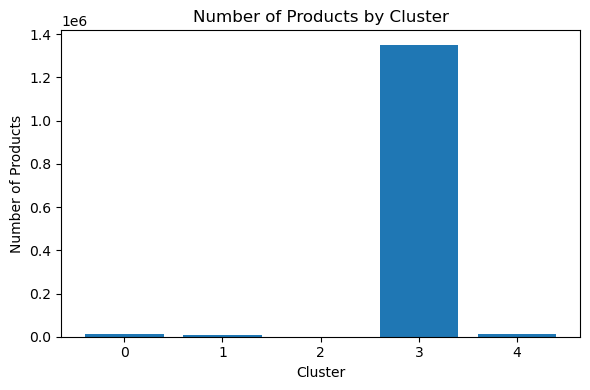

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["num_products"])
plt.title("Number of Products by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

A normalized heatmap was generated to visualize and compare the relative feature profiles of each cluster, highlighting differences in customer engagement, reach, and product characteristics.

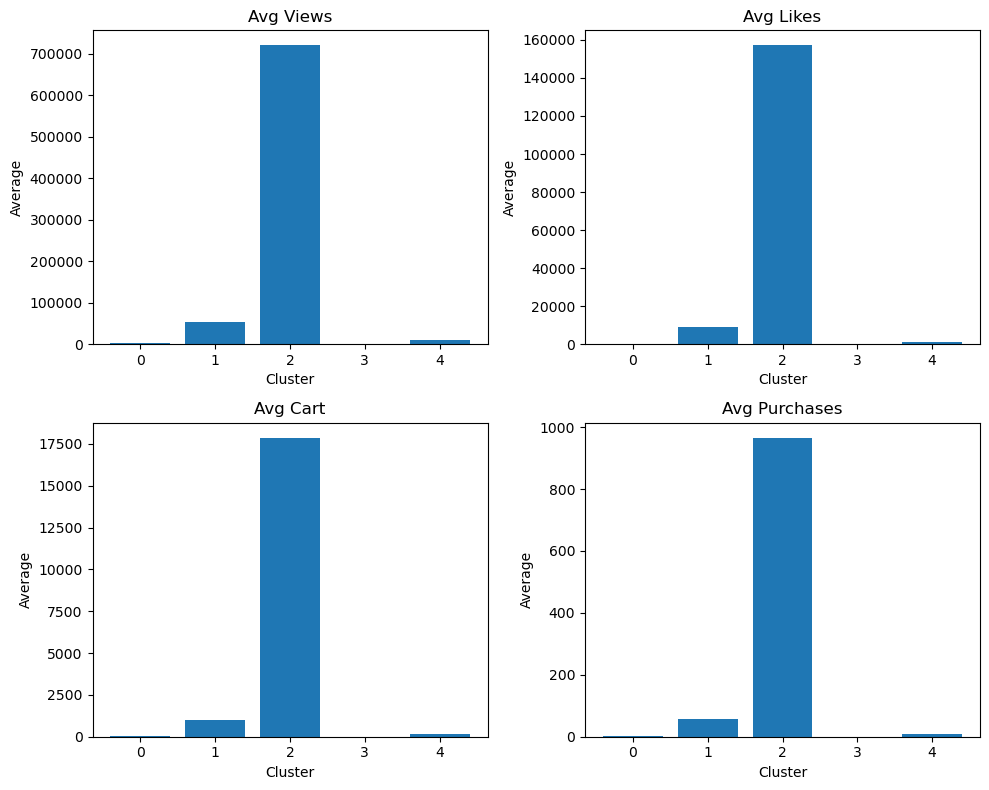

In [ ]:
features = ["avg_views", "avg_likes", "avg_cart", "avg_purchases"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.bar(cluster_summary.index.astype(str), cluster_summary[feature])
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Average")

plt.tight_layout()
plt.show()

PCA was used to project the clustered data into two dimensions for visualization of the cluster distribution and separation.

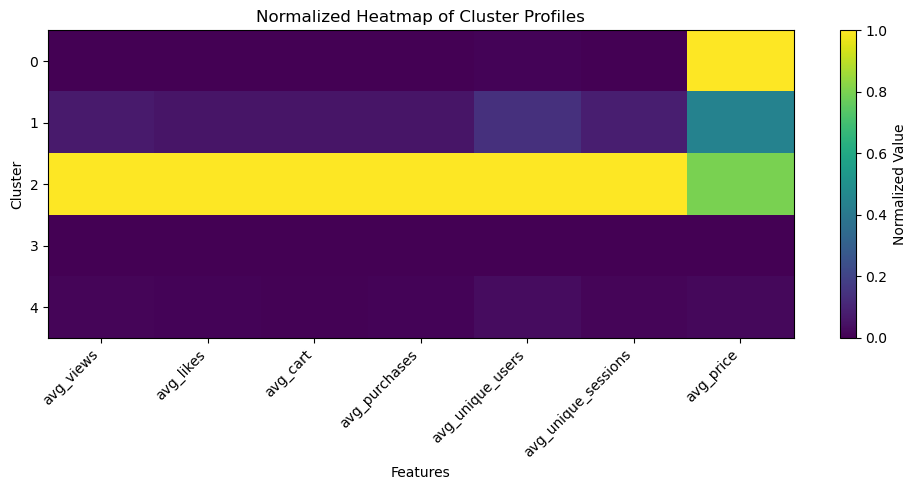

In [ ]:
heatmap_data = cluster_summary[
    [
        "avg_views",
        "avg_likes",
        "avg_cart",
        "avg_purchases",
        "avg_unique_users",
        "avg_unique_sessions",
        "avg_price",
    ]
]

normalized = MinMaxScaler().fit_transform(heatmap_data)

plt.figure(figsize=(10, 5))
plt.imshow(normalized, aspect="auto")
plt.colorbar(label="Normalized Value")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(cluster_summary.index)), cluster_summary.index)

plt.xlabel("Features")
plt.ylabel("Cluster")
plt.title("Normalized Heatmap of Cluster Profiles")

plt.tight_layout()
plt.show()